In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df= pd.read_csv('imbd orginal.csv')



In [72]:
df=df.dropna(subset=['Year','Genre','Rating'])
df['Year']=df['Year'].astype(int)
df.isna().sum()



Poster               0
Title                0
Year                 0
Certificate       2226
Duration (min)       9
Genre                0
Rating               0
Metascore         1992
Director             0
Cast                 7
Votes                0
Description          0
Review Count         1
Review Title       114
Review             113
dtype: int64

In [73]:
df=df.rename(columns={'Rating(out of 10)': 'Rating','Metascore':'Metascore(out of 100)'})
df=df.drop(columns=['Review Title'])

In [74]:
df_exploded=df.assign(Genre=df['Genre'].str.split(',')).explode('Genre')
df_exploded=df_exploded[['Genre','Rating','Year','Title']]
df_exploded.sort_values(['Genre','Rating'],ascending=[True,False])
top3_per_genre=df_sorted.groupby(['Genre','Year']).head(3).reset_index(drop=True)
top3_per_genre

,Genre,Rating,Year,Title
0,Action,8.6,2006,Spider-Man: Across the Spider-Verse
1,Action,8.4,2012,Spider-Man: Into the Spider-Verse
2,Action,8.3,2016,Mononoke-hime
3,Action,8.3,1969,The Rescue
4,Action,8.2,2009,GekijÃ´-ban Kimetsu no Yaiba Mugen Ressha-hen
...,...,...,...,...
4398,Western,6.0,2023,Colt .45
4399,Western,5.6,2020,Far Haven
4400,Western,4.6,2002,Hot Spur
4401,Western,4.3,2012,Calamity Jane


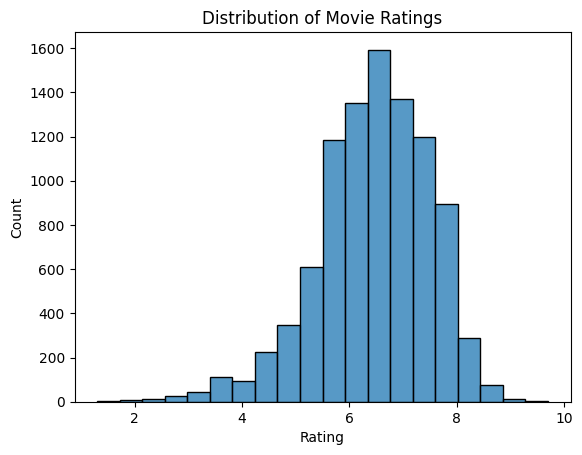

In [75]:
import seaborn as sns

sns.histplot(df['Rating'], bins=20)

plt.title("Distribution of Movie Ratings")
plt.show()

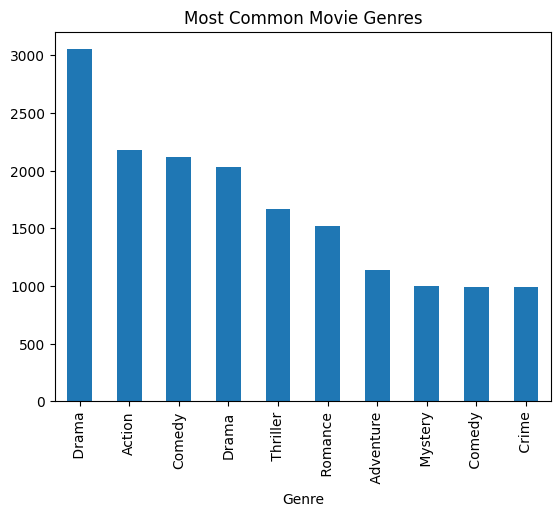

In [76]:
all_genres = df['Genre'].str.split(',').explode()
top=all_genres.value_counts().head(10)
top.plot(kind='bar')
plt.title("Most Common Movie Genres")
plt.show()

In [77]:
# function that recommend a movie by genre and year range
df_func=df[['Title','Genre','Rating','Cast','Description','Year']]
def recommended_movies(df,genre,start_year,end_year):
   filtered = df[
       (df['Genre'].apply(lambda x: isinstance(x, str) and genre in x)) &
       (df['Year'] >= start_year) &
       (df['Year'] <= end_year)
                ]
   filtered=filtered.sort_values(by='Rating',ascending=False)
   return filtered.head(3)
    
    

In [78]:
recommended_movies(df_func,'Romance',2010,2015)

,Title,Genre,Rating,Cast,Description,Year
5159,Modern Times,"Comedy, Drama, Romance",8.5,"Charles Chaplin, Paulette Goddard, Henry Bergm...",The Tramp struggles to live in modern industri...,2010
7413,Voyna i mir,"Drama, Romance, War",8.3,"Lyudmila Saveleva, Vyacheslav Tikhonov, Sergey...",The Russian aristocracy prepares for the Frenc...,2015
1775,Some Like It Hot,"Comedy, Music, Romance",8.2,"Marilyn Monroe, Tony Curtis, Jack Lemmon, Geor...","After two male musicians witness a mob hit, th...",2014


In [79]:
from wordcloud import WordCloud, STOPWORDS
df['Genre']=df['Genre'].str.split(',')
df_exploded=df.explode('Genre')

#wordcloud function
def create_wordcloud(text):
    wordcloud = WordCloud(
        width=400,
        height=200,
        background_color='white',
        stopwords=STOPWORDS
    ).generate(str(text))
    
    fig,ax=plt.subplots()
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis("off")
    return fig

#recommending movies function
def recommend_movies(genre,start_year,end_year=None,top_n=3,df=None):
    if df is None:
        df=df_exploded
    if end_year is None:
        end_year=start_year
    
    #filter by genre and year
    df_filtered=df[
        (df['Genre']==genre)&
        (df['Year']>=start_year)&
        (df['Year']<=end_year)
    ]   
    df_filtered = df_filtered.sort_values(by='Rating', ascending=False).head(top_n)
    
    #display movie info and its wordcloud
    for i, row in df_filtered.iterrows():
        print(f"Title: {row['Title']},Year: {row['Year']}, Rating: {row['Rating']}")
        create_wordcloud(row['Review'])
        plt.show()
    return df_filtered[['Title','Year','Rating','Genre']]


        
    
    
    
    


Title: Some Like It Hot,Year: 2014, Rating: 8.2


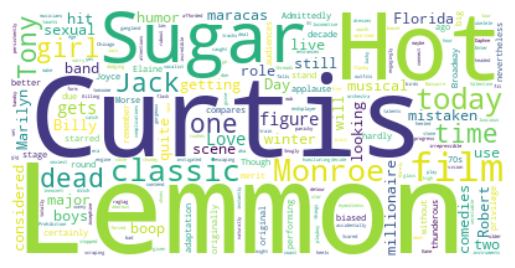

Title: Crna machka, beli machor,Year: 2014, Rating: 8.0


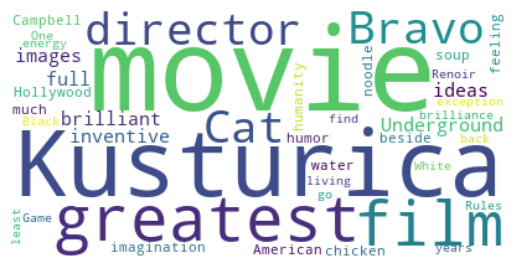

Title: Annie Hall,Year: 2014, Rating: 8.0


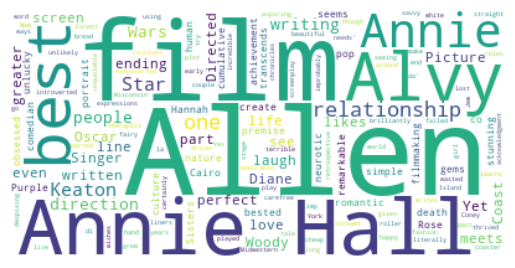

,Title,Year,Rating,Genre
1775,Some Like It Hot,2014,8.2,Comedy
9331,"Crna machka, beli machor",2014,8.0,Comedy
2786,Annie Hall,2014,8.0,Comedy


In [80]:

recommend_movies(genre='Comedy', start_year=2014)
